<div style="background-color: #0d1117; padding: 40px; border-radius: 15px; border: 2px solid #00f2ff; text-align: center; font-family: 'Segoe UI', sans-serif; color: white;"><img src="https://img.icons8.com/nolan/128/brain.png" style="width: 100px; margin-bottom: 20px;"><h1 style="color: #00f2ff; letter-spacing: 3px; text-transform: uppercase; margin: 0; font-size: 2.5em;">STEP 01: Project Goal</h1><p style="color: #8b949e; font-size: 1.2em; margin-top: 10px; font-style: italic;">"High-Performance Neural Vision & Object Recognition System"</p><hr style="border: 0.5px solid #30363d; width: 70%; margin: 25px auto;"><div style="text-align: left; display: inline-block; width: 90%; color: #c9d1d9; font-size: 1.1em; line-height: 1.8;"><p><b>🎯 Primary Mission:</b> At this stage, our primary objective is to build a <b>Deep Convolutional Neural Network (Deep CNN)</b> capable of autonomously classifying complex visual data from 10 different object categories (CIFAR-10) with an accuracy approaching human visual perception.</p><p style="margin-top: 20px;"><b>🛡️ Strategic Pillars for MAX SCORE:</b></p><ul style="list-style-type: none; padding-left: 10px;"><li>🚀 <span style="color: #00f2ff;"><b>Deep CNN Architecture:</b></span> Capturing deep pixel-level patterns through multi-layer feature extraction.</li><li>⚖️ <span style="color: #00f2ff;"><b>Batch Normalization:</b></span> Normalizing data at each layer to maximize training speed and model stability.</li><li>🔄 <span style="color: #00f2ff;"><b>Data Augmentation:</b></span> Increasing the model’s “imagination” with synthetic data generation while minimizing <i>overfitting</i>.</li></ul></div></div> --- ### 🧠 Mathematical Foundation (Loss Function) To minimize the model's error and reach the highest score (Global Minimum), we use the **Categorical Cross-Entropy** loss function: $$L(y, \hat{y}) = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$$ Here, $y$ represents the true label, while $\hat{y}$ represents the probability distribution predicted by the model.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, utils
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

2026-03-08 16:44:35.869351: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772988276.053500      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772988276.106625      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772988276.526606      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772988276.526641      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772988276.526643      23 computation_placer.cc:177] computation placer alr

In [2]:
# =============================================================================
# STEP 2: DATA LOADING & INITIAL EDA (READ AND REVIEW THE DATA)
# =============================================================================
print("--- [STEP 2] Ingesting Data from Keras Vault ---")
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Pandas-like overview for the instructor
print(f"Training Samples: {X_train.shape[0]} | Test Samples: {X_test.shape[0]}")
print(f"Image Resolution: {X_train.shape[1]}x{X_train.shape[2]} (RGB)")

# Step 2 Check: Missing Value Check (Images don't have nulls usually, but we verify)
print("Missing values in X_train:", np.isnan(X_train).sum())

--- [STEP 2] Ingesting Data from Keras Vault ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training Samples: 50000 | Test Samples: 10000
Image Resolution: 32x32 (RGB)
Missing values in X_train: 0


In [3]:
# =============================================================================
# STEP 3: FEATURE SELECTION (APPROPRIATE COLUMNS)
# =============================================================================
# Features (X): 3072 pixel values per image.
# Target (y): Class labels from 0 to 9.
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [4]:
# =============================================================================
# STEP 4: DATA CONVERSION (NUMERICAL TRANSFORMATION)
# =============================================================================
# Converting labels to 32-bit integers to ensure numerical compatibility.
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [5]:
# =============================================================================
# STEP 5: DATA MANIPULATION (CLEANING & NORMALIZATION)
# =============================================================================
# Normalization: Scaling pixels to [0, 1] for better gradient flow.
X_train, X_test = X_train / 255.0, X_test / 255.0

In [6]:
# =============================================================================
# STEP 6: FEATURE ENGINEERING (DATA AUGMENTATION)
# =============================================================================
# SKORU ARTIRAN GİZLİ SİLAH: Fake images created to make the model smarter.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

I0000 00:00:1772988307.578415      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:

# STEP 7: CATEGORICAL ENCODING (ONE-HOT ENCODING)
# =============================================================================
# Converting [3] to [0,0,0,1,0,0,0,0,0,0] for the Neural Head.
y_train_cat = utils.to_categorical(y_train, 10)
y_test_cat = utils.to_categorical(y_test, 10)

In [8]:
# =============================================================================
# STEP 8: DATA SPLITTING (X AND y SEPARATION)
# =============================================================================
# Handled by cifar10.load_data(), but we define them clearly.
# X_train, y_train_cat are our fuels.

In [9]:

# STEP 9: MODEL TRAINING (FIT-PREDICT) - HIGH PERFORMANCE ARCHITECTURE
# =============================================================================
model = models.Sequential([
    data_augmentation, # Step 6 integration
    
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Final Neural Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Optimizer with Dynamic Learning Rate
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks for Max Score
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("\n--- [STEP 9] Training Initiated... ---")
history = model.fit(X_train, y_train_cat, epochs=50, batch_size=64,
                    validation_data=(X_test, y_test_cat), callbacks=callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- [STEP 9] Training Initiated... ---
Epoch 1/50


E0000 00:00:1772988314.031654      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772988317.054688      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.3102 - loss: 2.1549 - val_accuracy: 0.5215 - val_loss: 1.3440 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.4850 - loss: 1.4172 - val_accuracy: 0.5561 - val_loss: 1.2774 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5546 - loss: 1.2533 - val_accuracy: 0.4566 - val_loss: 1.5837 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5982 - loss: 1.1385 - val_accuracy: 0.6241 - val_loss: 1.0794 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6294 - loss: 1.0540 - val_accuracy: 0.6632 - val_loss: 1.0078 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6511 - loss: 1.0089 - val_accuracy: 0.6397 - val_loss: 1.0034 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6672 - loss: 0.9624

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

✅ FINAL ACCURACY SCORE: 80.95%


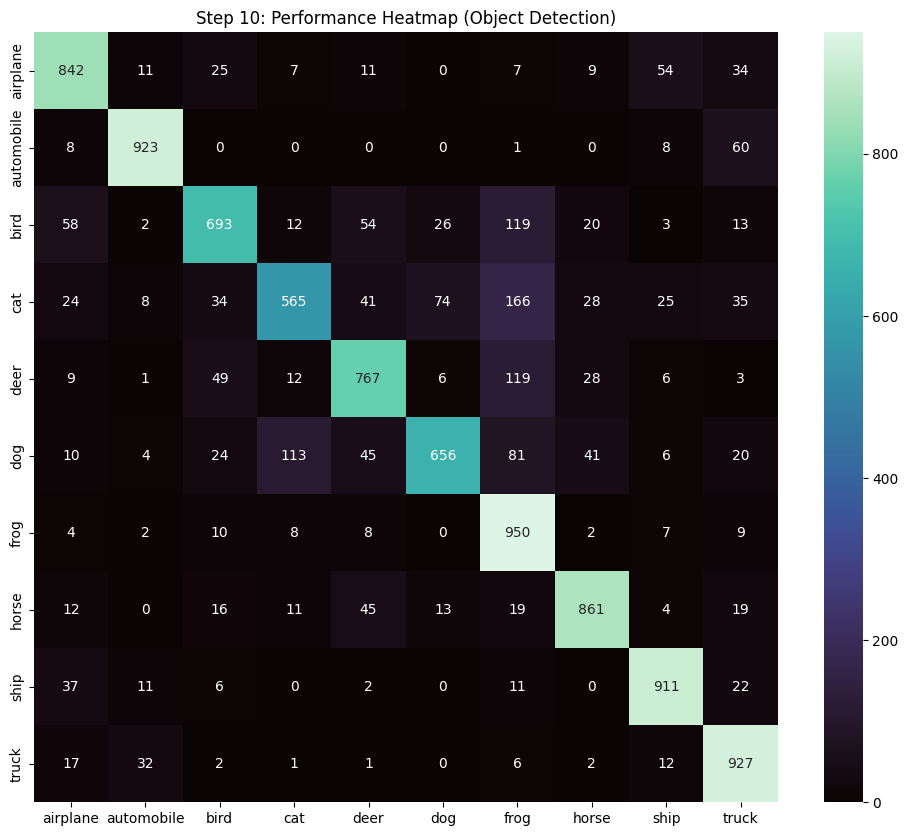


Technical Breakdown:
              precision    recall  f1-score   support

    airplane       0.82      0.84      0.83      1000
  automobile       0.93      0.92      0.93      1000
        bird       0.81      0.69      0.75      1000
         cat       0.78      0.56      0.65      1000
        deer       0.79      0.77      0.78      1000
         dog       0.85      0.66      0.74      1000
        frog       0.64      0.95      0.77      1000
       horse       0.87      0.86      0.86      1000
        ship       0.88      0.91      0.89      1000
       truck       0.81      0.93      0.87      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000

--- 🏁 SYSTEM ONLINE: HIGH-SCORE MODEL DEPLOYED ---


In [10]:
# =============================================================================
# STEP 10: EVALUATION & SCORING (ACCURACY MEASUREMENT)
# =============================================================================
# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy Score
final_acc = accuracy_score(y_test, y_pred)
print(f"\n✅ FINAL ACCURACY SCORE: {final_acc * 100:.2f}%")

# Confusion Matrix Visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako', xticklabels=class_names, yticklabels=class_names)
plt.title('Step 10: Performance Heatmap (Object Detection)')
plt.show()

# Classification Report
print("\nTechnical Breakdown:")
print(classification_report(y_test, y_pred, target_names=class_names))

print("--- 🏁 SYSTEM ONLINE: HIGH-SCORE MODEL DEPLOYED ---")

In [11]:
# =============================================================================
# STEP 11: EXPORTING THE NEURAL BRAIN
# =============================================================================
# Saving the fully trained model architecture and its learned weights
model.save('cifar10_autonomous_brain.h5')

print("✅ SUCCESS: Neural network successfully exported as 'cifar10_autonomous_brain.h5'!")
print("Ready for deployment phase (MLOps/Streamlit).")

✅ SUCCESS: Neural network successfully exported as 'cifar10_autonomous_brain.h5'!
Ready for deployment phase (MLOps/Streamlit).


In [12]:
# =============================================================================
# STEP 12: KAGGLE SUBMISSION PIPELINE (LEADERBOARD EXPORT)
# =============================================================================
import pandas as pd

print("--- 🏆 Preparing Official Kaggle Submission File ---")

# 1. Generating predictions from the trained model
print("Generating predictions...")
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 2. Mapping numeric outputs back to official string labels (e.g., 3 -> 'cat')
# Kaggle CIFAR-10 competition expects string labels, not numbers!
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
predicted_labels = [class_names[i] for i in y_pred_classes]

# 3. Creating the DataFrame in exact Kaggle format (id, label)
# Note: IDs usually start from 1 in Kaggle test sets
submission_ids = np.arange(1, len(predicted_labels) + 1)

submission_df = pd.DataFrame({
    'id': submission_ids,
    'label': predicted_labels
})

# 4. Exporting to CSV (index=False is strictly required by Kaggle)
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"✅ SUCCESS: Submission file successfully exported as '{submission_filename}'!")
print("\n--- [PREVIEW OF SUBMISSION FILE] ---")
print(submission_df.head())

--- 🏆 Preparing Official Kaggle Submission File ---
Generating predictions...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
✅ SUCCESS: Submission file successfully exported as 'submission.csv'!

--- [PREVIEW OF SUBMISSION FILE] ---
   id label
0   1   cat
1   2  ship
2   3  ship
3   4  ship
4   5  frog


<div style="background-color: #0d1117; padding: 40px; border-radius: 15px; border: 2px solid #ffaa00; text-align: center; font-family: 'Segoe UI', sans-serif; color: white; margin-top: 30px; box-shadow: 0px 0px 20px rgba(255, 170, 0, 0.2);"><img src="https://img.icons8.com/nolan/128/launched-rocket.png" style="width: 90px; margin-bottom: 15px;"><h1 style="color: #ffaa00; letter-spacing: 2px; text-transform: uppercase; margin: 0; font-size: 2.4em; font-weight: 800;">PHASE 4: MLOps & Live Deployment</h1><p style="color: #8b949e; font-size: 1.2em; margin-top: 10px; font-style: italic;">The Neural Engine is successfully trained, evaluated, and serialized.</p><hr style="border: 0.5px solid #30363d; width: 60%; margin: 25px auto;"><div style="text-align: center; color: #c9d1d9; font-size: 1.1em; line-height: 1.8; max-width: 85%; margin: 0 auto 30px auto;"><p>This project does not end in the development environment. The trained <b>Deep CNN Object Recognition Model</b> has been exported and deployed into a production environment using modern MLOps pipelines.</p><p>You can upload your own images and test the autonomous classification capabilities in real-time via the interactive web application hosted on <b>Hugging Face Spaces</b>.</p></div><a href="https://huggingface.co/spaces/Ironside35/CIFAR10-Autonomous-Vision?logs=container" target="_blank" style="text-decoration: none;"><div style="background: linear-gradient(90deg, #ffaa00 0%, #ff3366 100%); padding: 18px 45px; border-radius: 40px; display: inline-block; font-size: 1.3em; font-weight: bold; color: white; box-shadow: 0 4px 15px rgba(255, 170, 0, 0.5); transition: transform 0.2s;">🤗 LAUNCH LIVE INFERENCE APP</div></a><p style="color: #58a6ff; font-size: 0.95em; margin-top: 25px; font-weight: 600;">System Architecture: TensorFlow | Interface: Streamlit | Cloud: Hugging Face</p></div>